In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from  ydata_profiling import ProfileReport

warnings.filterwarnings("ignore")
%matplotlib inline

In [27]:
dataset = pd.read_csv("apple_prices_dataset.csv")
dataset.drop(columns=["Date", "Record_ID"], inplace=True)
dataset.sample(5)

,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
418,Japan,Pink Lady,Standard,Online Store,4.11,664,2729.04
177,Australia,Honeycrisp,Premium,Wholesale Market,3.31,429,1419.99
472,Saudi Arabia,Pink Lady,Economy,Local Market,3.62,139,503.18
76,Saudi Arabia,Red Delicious,Economy,Wholesale Market,0.94,87,81.78
160,France,Pink Lady,Economy,Wholesale Market,3.77,1562,5888.74


In [28]:
report = ProfileReport(df=dataset, title="Appple Prices")
report.to_file("profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 93206.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
label_cols = ["Country", "Apple_Variety", "Market_Type"]


from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
le = LabelEncoder()


for i in dataset[label_cols]:

    dataset[i] = le.fit_transform(dataset[i])

ord_data = [['Premium', 'Standard', 'Economy']]

oe = OrdinalEncoder(categories=ord_data)
dataset["Quality_Grade"] = oe.fit_transform(dataset[["Quality_Grade"]])
dataset.sample(5)

,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
119,2,0,2.0,1,1.42,381,541.02
102,8,0,1.0,2,3.64,1880,6843.20
367,6,1,1.0,3,1.86,787,1463.82
316,12,3,0.0,2,4.11,1333,5478.63
310,6,5,0.0,2,1.47,125,183.75


In [30]:
dataset.describe()

,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.856000,2.970000,0.986000,1.554000,2.674440,1020.458000,2661.852900
std,3.746911,2.013258,0.806912,1.139157,1.069996,578.570393,1887.389644
min,0.000000,0.000000,0.000000,0.000000,0.810000,50.000000,49.500000
25%,3.000000,1.000000,0.000000,0.000000,1.740000,511.250000,1165.857500
50%,6.000000,3.000000,1.000000,2.000000,2.685000,1044.000000,2330.265000
75%,9.000000,5.000000,2.000000,3.000000,3.602500,1534.250000,3840.607500
max,12.000000,6.000000,2.000000,3.000000,4.490000,1999.000000,8461.560000


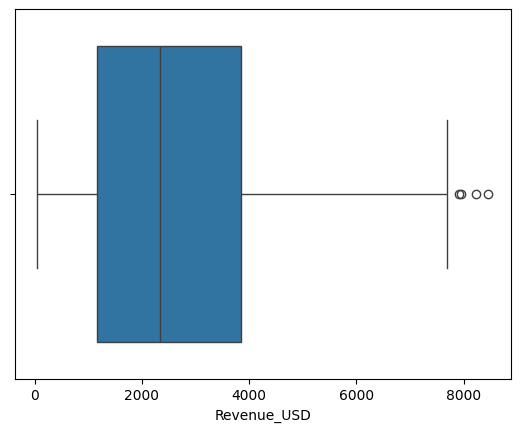

In [31]:
sns.boxplot(x=dataset["Revenue_USD"])
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset.iloc[:,:-1], dataset.Revenue_USD, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=90)
rf_model.fit(X_train, y_train)

print(rf_model.score(X_test, y_test)*100)
print(rf_model.score(X_train, y_train)*100)

99.04681196407812
99.3551656886148


In [34]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
rmse = root_mean_squared_error(y_test, rf_model.predict(X_test))
r2score = r2_score(y_test, rf_model.predict(X_test))
mae = mean_absolute_error(y_test, rf_model.predict(X_test))
print(r2score)
print(rmse)
print(mae)

0.9904681196407812
178.7914245012722
133.6885905822015


In [35]:
y_test.mean()

np.float64(2601.3222)

In [36]:
import joblib

joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [45]:
print(*dataset.columns)

Country Apple_Variety Quality_Grade Market_Type Price_per_KG_USD Quantity_Sold_KG Revenue_USD
